# Avaliação de desempenho de uma política pública com DEA

Este notebook aplica **Análise Envoltória de Dados (DEA)** aos indicadores de desenvolvimento humano do arquivo `dea_desenv_humano.csv`. A atividade segue a proposta do notebook-base: comparar regiões (DMUs) usando a renda como recurso e expectativa de vida, conhecimento e satisfação como resultados.

> **Nota metodológica:** DEA mede eficiência relativa, não identifica sozinho um efeito causal. Assim, aqui “impacto” significa desempenho relativo compatível com melhor conversão de recursos em resultados. Para estimar causalidade seriam necessários contrafactual, grupo de comparação e dimensão temporal, entre outros pressupostos.

## 1. Pergunta, unidades e especificação

**Pergunta:** quais regiões apresentam as melhores práticas relativas na transformação de renda em resultados de desenvolvimento humano?

- DMUs: regiões identificadas por `dmu`;
- input: `Renda`;
- outputs: `ExpecVida`, `Conhecimento` e `Satisfacao`;
- modelo principal: BCC (retornos variáveis de escala), orientado a outputs;
- comparação: CCR (retornos constantes de escala), também orientado a outputs.

A orientação a outputs responde quanto os resultados poderiam crescer, proporcionalmente, mantendo a renda observada. O BCC é o modelo principal porque permite que regiões operem em escalas distintas.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linprog

pd.set_option('display.precision', 4)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Leitura portável e auditoria dos dados

In [ ]:
DATA_FILE = Path('dea/dea_desenv_humano.csv')

if DATA_FILE is None:
    raise FileNotFoundError('Arquivo dea_desenv_humano.csv não encontrado. Ajuste a lista candidatos.')

df = pd.read_csv(DATA_FILE)
print(f'Arquivo: {DATA_FILE.resolve()} | dimensão: {df.shape}')
display(df)

Arquivo: /workspaces/mcdia/10-adap/03-dea-rdd/dea/dea_desenv_humano.csv | dimensão: (10, 5)


,dmu,Renda,ExpecVida,Conhecimento,Satisfacao
0,N,11436,56.7,2.0,7.5
1,A1,5122,48.6,1.4,8.0
2,A2,6714,45.8,1.8,7.0
3,A3,950,38.7,0.5,5.0
4,A4,2200,37.0,0.9,4.5
5,A5,500,35.0,0.8,3.5
6,A6,3000,48.5,1.2,6.5
7,A7,4200,52.0,1.7,6.0
8,A8,1780,50.6,1.0,3.0
9,A9,7000,59.0,1.5,9.0


In [13]:
variaveis = ['Renda', 'ExpecVida', 'Conhecimento', 'Satisfacao']
esperadas = ['dmu', *variaveis]
faltantes = set(esperadas) - set(df.columns)
assert not faltantes, f'Colunas ausentes: {faltantes}'
assert df['dmu'].is_unique, 'Cada DMU deve aparecer uma única vez.'
assert not df[esperadas].isna().any().any(), 'Há valores ausentes.'
assert (df[variaveis] > 0).all().all(), 'DEA requer valores estritamente positivos nesta aplicação.'

display(df[variaveis].describe().T)
print('Duplicatas completas:', int(df.duplicated().sum()))

,count,mean,std,min,25%,50%,75%,max
Renda,10.0,4290.20,3380.2945,500.0,1885.000,3600.00,6316.000,11436.0
ExpecVida,10.0,47.19,8.1297,35.0,40.475,48.55,51.650,59.0
Conhecimento,10.0,1.28,0.4826,0.5,0.925,1.30,1.650,2.0
Satisfacao,10.0,6.00,1.9720,3.0,4.625,6.25,7.375,9.0


Duplicatas completas: 0


### Adequação e limitações da amostra

Há somente 10 DMUs e quatro variáveis no modelo. Pela regra prática $n \geq \max\{m \times s, 3(m+s)\}$, seriam recomendadas pelo menos 12 DMUs para 1 input e 3 outputs. Portanto, existe risco de muitas unidades aparecerem eficientes e os resultados devem ser tratados como exploratórios. As variáveis também precisam ser comparáveis e pertencer ao mesmo período; o CSV não traz metadados para confirmar essas condições.

## 3. Implementação DEA pela forma envelope

Para cada DMU $o$, o modelo BCC orientado a outputs maximiza $\phi$, sujeito a $X\lambda \leq x_o$, $Y\lambda \geq \phi y_o$, $\sum \lambda=1$ e $\lambda \geq0$. O escore reportado é $1/\phi$, limitado ao intervalo $(0,1]$. Os coeficientes $\lambda$ identificam os benchmarks e geram metas de output. No CCR, retira-se a restrição de convexidade $\sum \lambda=1$.

In [14]:
def dea_output_envelope(X, Y, retornos='VRS', tol=1e-7):
    """DEA radial orientado a outputs; retorna eficiência, expansão, lambdas e metas."""
    X, Y = np.asarray(X, float), np.asarray(Y, float)
    n = X.shape[0]
    resultados = []

    for o in range(n):
        # z = [lambda_1, ..., lambda_n, phi]; linprog minimiza -phi
        c = np.r_[np.zeros(n), -1.0]
        A_ub = np.vstack([
            np.c_[X.T, np.zeros(X.shape[1])],
            np.c_[-Y.T, Y[o]],
        ])
        b_ub = np.r_[X[o], np.zeros(Y.shape[1])]
        if retornos.upper() == 'VRS':
            A_eq, b_eq = np.c_[np.ones((1, n)), 0.0], np.array([1.0])
        elif retornos.upper() == 'CRS':
            A_eq = b_eq = None
        else:
            raise ValueError("retornos deve ser 'VRS' ou 'CRS'")

        sol = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                      bounds=[(0, None)] * n + [(1, None)], method='highs')
        if not sol.success:
            raise RuntimeError(f'Falha na DMU {o}: {sol.message}')
        lambdas, phi = sol.x[:-1], sol.x[-1]
        resultados.append({
            'eficiencia': min(1.0, 1.0 / phi),
            'expansao_radial': phi,
            'lambdas': np.where(lambdas > tol, lambdas, 0.0),
            'meta_output': lambdas @ Y,
            'folga_output': lambdas @ Y - phi * Y[o],
        })
    return resultados

## 4. Estimação do modelo principal e comparação

In [15]:
inputs = ['Renda']
outputs = ['ExpecVida', 'Conhecimento', 'Satisfacao']
X = df[inputs].to_numpy(float)
Y = df[outputs].to_numpy(float)

res_bcc = dea_output_envelope(X, Y, retornos='VRS')
res_ccr = dea_output_envelope(X, Y, retornos='CRS')

resultado = df.copy()
resultado['ef_bcc'] = [r['eficiencia'] for r in res_bcc]
resultado['ef_ccr'] = [r['eficiencia'] for r in res_ccr]
resultado['ef_escala'] = (resultado['ef_ccr'] / resultado['ef_bcc']).clip(upper=1)
resultado['aumento_radial_pct'] = 100 * ([r['expansao_radial'] for r in res_bcc] - np.ones(len(df)))
resultado['status_bcc'] = np.where(resultado['ef_bcc'] >= 1 - 1e-6, 'Eficiente', 'Ineficiente')
display(resultado.sort_values(['ef_bcc', 'dmu'], ascending=[False, True]))

,dmu,Renda,ExpecVida,Conhecimento,Satisfacao,ef_bcc,ef_ccr,ef_escala,aumento_radial_pct,status_bcc
1,A1,5122,48.6,1.4,8.0,1.0000,0.2231,0.2231,0.0000e+00,Eficiente
3,A3,950,38.7,0.5,5.0,1.0000,0.7519,0.7519,0.0000e+00,Eficiente
5,A5,500,35.0,0.8,3.5,1.0000,1.0000,1.0000,0.0000e+00,Eficiente
6,A6,3000,48.5,1.2,6.5,1.0000,0.3095,0.3095,-1.1102e-14,Eficiente
8,A8,1780,50.6,1.0,3.0,1.0000,0.4061,0.4061,0.0000e+00,Eficiente
0,N,11436,56.7,2.0,7.5,1.0000,0.1093,0.1093,0.0000e+00,Eficiente
2,A2,6714,45.8,1.8,7.0,1.0000,0.1676,0.1676,2.2204e-14,Eficiente
7,A7,4200,52.0,1.7,6.0,1.0000,0.2530,0.2530,2.2204e-14,Eficiente
9,A9,7000,59.0,1.5,9.0,1.0000,0.1837,0.1837,2.2204e-14,Eficiente
4,A4,2200,37.0,0.9,4.5,0.8327,0.2922,0.3509,2.0088e+01,Ineficiente


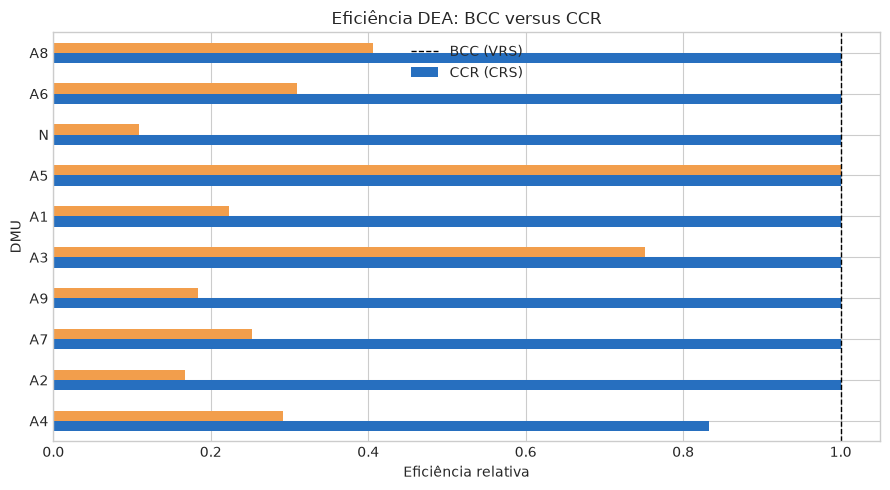

In [16]:
ax = resultado.sort_values('ef_bcc').plot.barh(
    x='dmu', y=['ef_bcc', 'ef_ccr'], figsize=(9, 5), color=['#276FBF', '#F29E4C']
)
ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set(xlabel='Eficiência relativa', ylabel='DMU', title='Eficiência DEA: BCC versus CCR')
ax.legend(['BCC (VRS)', 'CCR (CRS)'])
plt.tight_layout();

## 5. Metas e unidades de referência

Para uma unidade ineficiente, `aumento_radial_pct` indica o crescimento proporcional mínimo dos três outputs para alcançar a fronteira. As metas abaixo incorporam também eventuais folgas. Elas representam referências relativas da amostra, não previsões automáticas nem metas causais garantidas.

In [17]:
linhas_meta = []
for i, r in enumerate(res_bcc):
    pares = [(df.loc[j, 'dmu'], peso) for j, peso in enumerate(r['lambdas']) if peso > 1e-7]
    referencias = ', '.join(f'{dmu} ({peso:.3f})' for dmu, peso in pares)
    linha = {
        'dmu': df.loc[i, 'dmu'],
        'ef_bcc': r['eficiencia'],
        'aumento_radial_pct': 100 * (r['expansao_radial'] - 1),
        'benchmarks': referencias,
    }
    for k, nome in enumerate(outputs):
        linha[f'{nome}_observado'] = Y[i, k]
        linha[f'{nome}_meta'] = r['meta_output'][k]
    linhas_meta.append(linha)

metas = pd.DataFrame(linhas_meta)
display(metas.query('ef_bcc < 1 - 1e-6').sort_values('ef_bcc'))

,dmu,ef_bcc,aumento_radial_pct,benchmarks,ExpecVida_observado,ExpecVida_meta,Conhecimento_observado,Conhecimento_meta,Satisfacao_observado,Satisfacao_meta
4,A4,0.8327,20.0877,"A5 (0.315), A6 (0.617), A7 (0.029), A8 (0.039)",37.0,44.4324,0.9,1.0808,4.5,5.4039


## 6. Síntese automática dos achados

In [18]:
eficientes = resultado.loc[resultado['ef_bcc'] >= 1 - 1e-6, 'dmu'].tolist()
ineficientes = resultado.loc[resultado['ef_bcc'] < 1 - 1e-6].sort_values('ef_bcc')
print(f'DMUs eficientes no BCC: {eficientes}')
print(f'Eficiência BCC média: {resultado.ef_bcc.mean():.3f}')
if not ineficientes.empty:
    pior = ineficientes.iloc[0]
    print(f'Maior distância da fronteira: {pior.dmu}, eficiência {pior.ef_bcc:.3f} '          f'e expansão radial potencial de {pior.aumento_radial_pct:.1f}%.')
print(f'Eficiência de escala média: {resultado.ef_escala.mean():.3f}')

DMUs eficientes no BCC: ['N', 'A1', 'A2', 'A3', 'A5', 'A6', 'A7', 'A8', 'A9']
Eficiência BCC média: 0.983
Maior distância da fronteira: A4, eficiência 0.833 e expansão radial potencial de 20.1%.
Eficiência de escala média: 0.376


## 7. Análise de sensibilidade

Com uma amostra pequena e três outputs, os pesos flexíveis podem favorecer especializações. Como teste simples de robustez, reestimamos o BCC retirando um output por vez. Mudanças grandes de classificação indicam que a conclusão depende da escolha dos indicadores.

In [19]:
sensibilidade = pd.DataFrame({'dmu': df['dmu'], 'modelo_completo': resultado['ef_bcc']})
for removida in outputs:
    cols = [c for c in outputs if c != removida]
    teste = dea_output_envelope(X, df[cols].to_numpy(float), retornos='VRS')
    sensibilidade[f'sem_{removida}'] = [r['eficiencia'] for r in teste]

display(sensibilidade.set_index('dmu').style.background_gradient(cmap='RdYlGn', vmin=0, vmax=1))

,modelo_completo,sem_ExpecVida,sem_Conhecimento,sem_Satisfacao
dmu,,,,
N,1.000000,1.000000,0.961017,1.000000
A1,1.000000,1.000000,1.000000,0.889664
A2,1.000000,1.000000,0.792279,0.997656
A3,1.000000,1.000000,1.000000,0.955924
A4,0.832725,0.827258,0.808849,0.776944
A5,1.000000,1.000000,1.000000,1.000000
A6,1.000000,1.000000,1.000000,0.938128
A7,1.000000,1.000000,0.968471,1.000000
A8,1.000000,0.899805,1.000000,1.000000


## 8. Conclusão e recomendações

A fronteira BCC identifica as regiões que, **dentro desta amostra**, combinam renda e resultados de modo relativamente mais favorável. As unidades abaixo da fronteira recebem referências observadas e metas tecnicamente alcançáveis por combinações convexas das boas práticas. A diferença entre BCC e CCR revela a parcela associada à escala de operação.

Para que esta análise sustente uma avaliação de impacto de política pública mais forte, recomenda-se: (1) ampliar o número de municípios/regiões; (2) documentar fonte, período, população e deflacionamento da renda; (3) justificar a relação causal entre o recurso e cada resultado; (4) aplicar restrições de pesos ou reduzir outputs quando apropriado; (5) comparar períodos pré e pós-política com Índice de Malmquist; e (6) combinar os escores DEA com um desenho causal, como diferenças-em-diferenças ou RDD, sem tratar o escore DEA isolado como efeito causal.